In [1]:
"""
LSTM Flood Forecasting Model
Predicts streamflow 24 hours ahead using the top30 high flood-severity sites.
"""
import torch
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from src.preprocessing.preprocessing import processor
from src.models.lstm import LSTMModel
from src.utils.helpers import create_sequences

STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

TARGET = "streamflow_cfs_mean" 

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

In [2]:
pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.8 (182.2MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06892000"
	"06803495"
	"06449000"
	"06447500"
	"06450500"
	…
	"06935755"
	"06803500"
	"06834000"
	"06881000"
	"06820500"
]
(4818417, 31)


In [3]:
print("Creating sequences...")
X_train, y_train, train_site_ids = create_sequences(train_X, train_y, WINDOW_SIZE)
X_val, y_val, val_site_ids = create_sequences(val_X, val_y, WINDOW_SIZE)
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print("Sequences created.")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Creating sequences...
Sequences created.
Train: (2727758, 72, 28), Val: (338798, 72, 28), Test: (338699, 72, 28)


In [4]:
lstm = LSTMModel(
    lstm_units=(32, 16),
    dense_units=64,
    dropout_rate=0.3,
    under_predict_penalty=1.0,
    learning_rate=1e-3,
)

lstm.build(input_shape=(WINDOW_SIZE, X_train.shape[2]))
lstm.summary()

# %%
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

lstm.fit(
    (X_train, y_train),
    val_ds=(X_val, y_val),
    epochs=50,
    callbacks=[early_stopping],
    batch_size=32,
)

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 32)         │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,097 (47.25 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1033s 12ms/step - loss: 0.2711 - mae: 0.1489 - val_loss: 0.2586 - val_mae: 0.1299
Epoch 2/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1018s 12ms/step - loss: 0.2481 - mae: 0.1394 - val_loss: 0.2558 - val_mae: 0.1244
Epoch 3/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1026s 12ms/step - loss: 0.2333 - mae: 0.1360 - val_loss: 0.2975 - val_mae: 0.1379
Epoch 4/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1025s 12ms/step - loss: 0.2253 - mae: 0.1350 - val_loss: 0.2592 - val_mae: 0.1235
Epoch 5/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1023s 12ms/step - loss: 0.2144 - mae: 0.1325 - val_loss: 0.3308 - val_mae: 0.1291
Epoch 6/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1020s 12ms/step - loss: 0.2028 - mae: 0.1309 - val_loss: 0.2843 - val_mae: 0.1262
Epoch 7/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1025s 12ms/step - loss: 0.1970 - mae: 0.1300 - val_loss: 0.3154 - val_mae: 0.1476


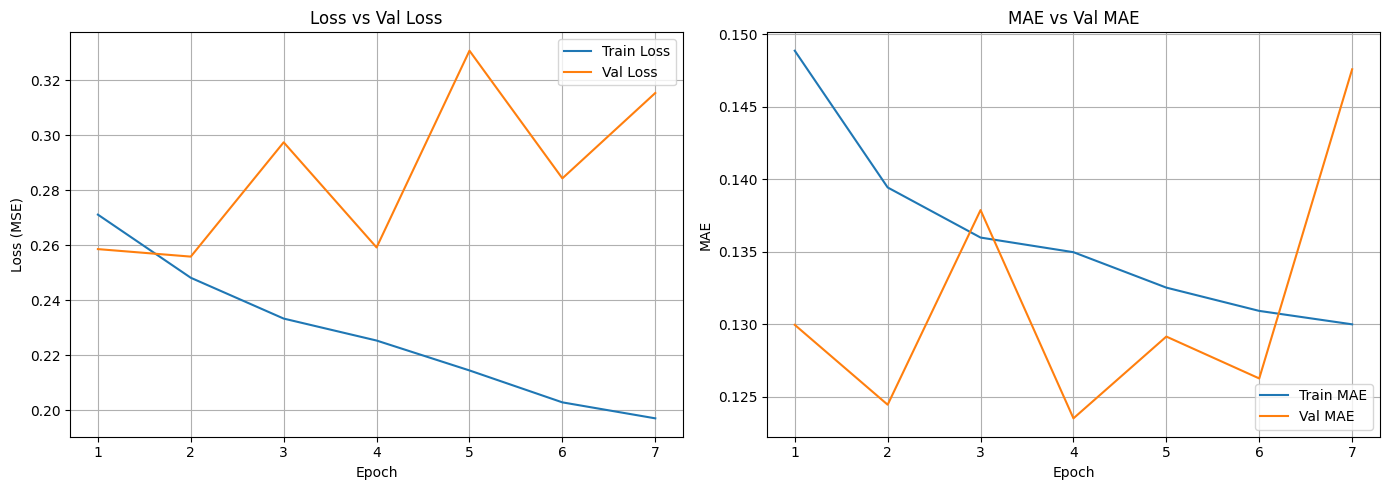

In [5]:
lstm.plot_training_history()

In [6]:
lstm.evaluate(X_test, y_test, test_site_ids, pcr.target_scaler)

10585/10585 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step
Site 06036650:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             2029.4 CFS       2043.3 CFS    200.0 CFS

Site 06061500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               54.8 CFS         86.9 CFS     40.4 CFS

Site 06093200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              202.0 CFS        193.7 CFS     48.7 CFS

Site 06188000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1434.5 CFS       1415.2 CFS    245.2 CFS

Site 06207500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1143.6 CFS       1112.7 CFS    181.8 CFS


10585/10585 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step


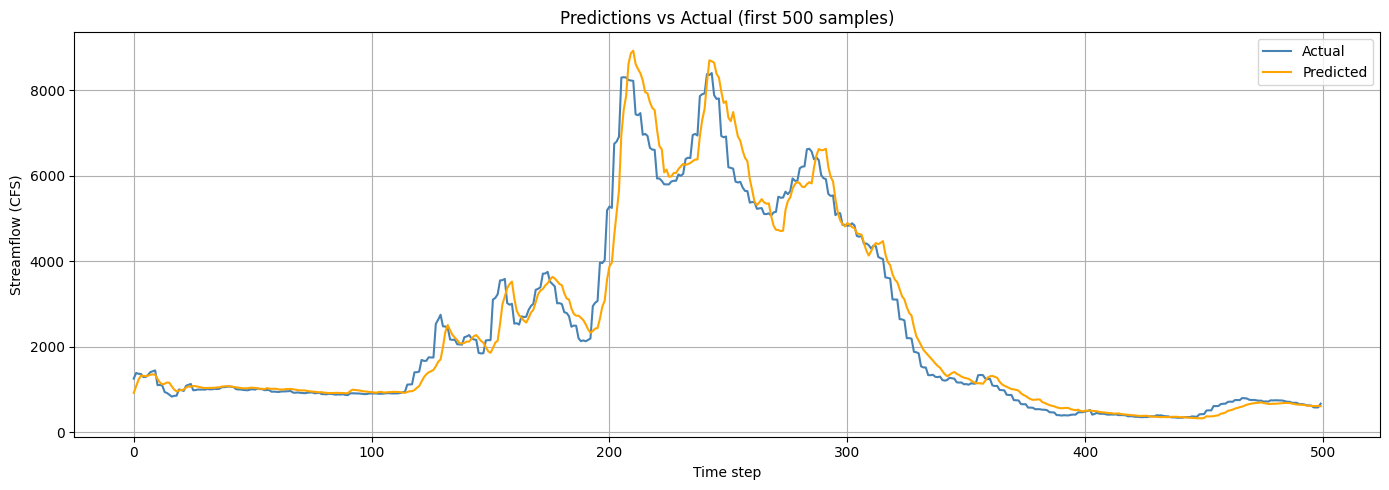

In [7]:
lstm.plot_results(X_test, y_test, pcr.target_scaler, n_samples=500)